# Docling Functionality Survey — Extraction & Parsing (No VLM)

This notebook is a hands-on tour of what **Docling** can do *on its own* — no vision-language
models, no chat-based captioning, no external LLM calls. The goal is to map out extraction
and parsing capabilities we can fold into the **Edenview** ingestion pipeline
(`edenview-rag/ingestion/extractor.py` and friends — see `edenview_plan.md`).

**Documents used** (from `data/sample_files/`):

| File | Pages | Why it's here |
|---|---|---|
| `covid-19-risk-factors-Japan.pdf` | 10 | Small, clean scientific PDF — quick full-document demos (OCR, confidence, visual grounding) |
| `wc-2026-regulations.pdf` | 50 (first 15 used) | Structured regulatory text with headings + tables — primary doc for structure/export/chunking |
| `vistra-20260331.pdf` | 104 (first 15 used) | Financial filing, dense tables — table extraction & TableFormer mode comparison |
| `infosys_filing_2026.pdf` | 384 (first 15 used) | Annual report, lots of logos/charts/figures — figure export & picture classification |
| `sample-files.com-large-document.docx` | ~50 (Word) | Word backend, no PDF pipeline involved |

We deliberately cap most PDF conversions to the first ~15 pages with `page_range`. Not just
for notebook speed: on this machine, letting a couple of these PDFs run end-to-end
intermittently trips a `std::bad_alloc` in the native PDF backend somewhere past page ~20
(reproduced deliberately in section 9). Capping `page_range` sidesteps it; section 9 covers
detecting/handling it instead of pretending it can't happen.

**What's deliberately out of scope:** `do_picture_description` (VLM captioning), the VLM
full-page conversion pipeline (GraniteDocling/SmolDocling), and anything requiring a remote
API key. Everything below runs fully local and offline after the (small) model downloads on
first use.

**Environment notes:** this machine is CPU-only. Docling's default OCR engine auto-selects
**RapidOCR** (pure ONNX runtime, already installed) since EasyOCR/Tesseract aren't present.
We also disable `torch.compile` below — on Windows without an MSVC compiler (`cl.exe`) on
PATH, Torch's inductor backend fails, which crashes any pipeline stage that tries to compile
(e.g. the picture classifier). This is a one-line fix, not a Docling limitation.


In [3]:

import os
import sys
import time
import json
import logging
from pathlib import Path

os.environ.setdefault("PYTHONIOENCODING", "utf-8")
logging.basicConfig(level=logging.WARNING)  # keep Docling's per-page INFO logs quiet

# Must happen before any DocumentConverter is created: avoids Torch inductor trying
# to shell out to `cl.exe` (MSVC), which isn't installed on this machine.
from docling.datamodel.settings import settings
settings.inference.compile_torch_models = False

import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/sample_files").resolve()
OUT_DIR = Path("scratch").resolve()
OUT_DIR.mkdir(exist_ok=True)

QUICK_PDF = DATA_DIR / "covid-19-risk-factors-Japan.pdf"       # 10 pages
PRIMARY_PDF = DATA_DIR / "wc-2026-regulations.pdf"             # 50 pages
FINANCIAL_PDF = DATA_DIR / "vistra-20260331.pdf"                # 104 pages
REPORT_PDF = DATA_DIR / "infosys_filing_2026.pdf"               # 384 pages
DOCX_FILE = DATA_DIR / "sample-files.com-large-document.docx"

for f in [QUICK_PDF, PRIMARY_PDF, FINANCIAL_PDF, REPORT_PDF, DOCX_FILE]:
    assert f.exists(), f"missing sample file: {f}"

from importlib.metadata import version as pkg_version

print("Docling version check:")
print(" docling:", pkg_version("docling"))
print(" docling-core:", pkg_version("docling-core"))


Docling version check:
 docling: 2.103.0
 docling-core: 2.82.0


## 1. Supported input/output formats (reference)

Docling ships backends for a wide range of formats without any VLM involved. From the
[Supported formats](https://docling-project.github.io/docling/usage/supported_formats/) docs:

**Input:** PDF, DOCX, XLSX, PPTX, Markdown, AsciiDoc, HTML, CSV, images (PNG/JPEG/TIFF/BMP/WEBP),
XML (JATS, USPTO patents, custom via `CustomXMLDocumentBackend`), EPUB, and audio (via a
separate ASR pipeline — not covered here since it isn't document parsing).

**Output:** Markdown, HTML, JSON (full `DoclingDocument` model), plain text, DocTags
(the tag-based format used to train/evaluate layout models), and a Pandas DataFrame for tables.

We exercise PDF and DOCX below using the sample files, then quickly prove out CSV and HTML
parsing with tiny synthetic files to show the breadth without needing extra sample data.


In [4]:

from docling.document_converter import DocumentConverter

# One converter with default settings is enough for the "does it parse at all" pass.
default_converter = DocumentConverter()

def convert_and_report(path, **kwargs):
    t0 = time.time()
    result = default_converter.convert(str(path), **kwargs)
    dt = time.time() - t0
    doc = result.document
    print(f"{path.name}")
    print(f"  status={result.status.name}  time={dt:.1f}s  pages={len(doc.pages)}")
    print(f"  texts={len(doc.texts)}  tables={len(doc.tables)}  pictures={len(doc.pictures)}  key_value_items={len(doc.key_value_items)}")
    return result

quick_res = convert_and_report(QUICK_PDF)
docx_res = convert_and_report(DOCX_FILE)


[INFO] 2026-07-05 14:54:38,720 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-07-05 14:54:38,720 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-07-05 14:54:38,720 [RapidOCR] main.py:65: Using D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-07-05 14:54:39,385 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-07-05 14:54:39,387 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-05 14:54:39,388 [RapidOCR] main.py:65: Using D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-05 14:54:39,482 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-07-05 14:54:39,48

covid-19-risk-factors-Japan.pdf
  status=SUCCESS  time=62.4s  pages=10
  texts=370  tables=4  pictures=4  key_value_items=0
sample-files.com-large-document.docx
  status=SUCCESS  time=1.6s  pages=0
  texts=547  tables=29  pictures=0  key_value_items=0


In [13]:

# Synthetic CSV + HTML to show format breadth beyond the PDFs/DOCX we have on disk.
csv_path = OUT_DIR / "toy_sales.csv"
csv_path.write_text(
    "region,quarter,revenue_usd\n"
    "APAC,Q1,1250000\n"
    "APAC,Q2,1310000\n"
    "EMEA,Q1,980000\n"
    "EMEA,Q2,1042000\n",
    encoding="utf-8",
)

html_path = OUT_DIR / "toy_page.html"
html_path.write_text(
    "<html><body><h1>Edenview Test Page</h1>"
    "<p>Docling can parse arbitrary <b>HTML</b> straight from disk or a URL.</p>"
    "<ul><li>Point one</li><li>Point two</li></ul></body></html>",
    encoding="utf-8",
)

csv_res = convert_and_report(csv_path)
html_res = convert_and_report(html_path)

print("\nCSV -> Markdown:\n", csv_res.document.export_to_markdown())
print("\nHTML -> Markdown:\n", html_res.document.export_to_markdown())


toy_sales.csv
  status=SUCCESS  time=0.0s  pages=0
  texts=0  tables=1  pictures=0  key_value_items=0
toy_page.html
  status=SUCCESS  time=0.1s  pages=0
  texts=6  tables=0  pictures=0  key_value_items=0

CSV -> Markdown:
 | region   | quarter   |   revenue_usd |
|----------|-----------|---------------|
| APAC     | Q1        |       1250000 |
| APAC     | Q2        |       1310000 |
| EMEA     | Q1        |        980000 |
| EMEA     | Q2        |       1042000 |

HTML -> Markdown:
 # Edenview Test Page

Docling can parse arbitrary **HTML** straight from disk or a URL.

- Point one
- Point two


In [22]:
print(quick_res.document.iterate_items())

<generator object DoclingDocument.iterate_items at 0x000001F181F270A0>


## 2. The `DoclingDocument` — a unified structure across formats

Every backend (PDF, DOCX, HTML, CSV, ...) converges on the same `DoclingDocument` pydantic
model. That's the whole point: one downstream chunking/serialization/export layer for any
input format. Key top-level containers:

- `texts` — paragraphs, headings, list items, captions... anything with a text body
- `tables` — `TableItem`, each can carry a recognized structure (rows/cols/cells)
- `pictures` — `PictureItem`, can carry classification/description/enrichment annotations
- `key_value_items` — form-style key/value pairs (from templated docs)
- `body` / `furniture` / `groups` — the hierarchy tree (reading order, headers/footers vs. main body)

`doc.iterate_items()` walks the body tree in reading order, giving you `(item, level)` pairs —
`level` reflects nesting depth, which is exactly what you need to reconstruct a heading
outline for a "jump to section" UI.


In [23]:

# Note: we cap this at 15 pages. Converting this particular PDF end-to-end on this
# (memory-constrained) machine intermittently hits a std::bad_alloc in the native PDF
# backend somewhere around pages 20-30 -- see the robustness callout in section 9, where
# we deliberately reproduce that failure and show how to detect it via `result.status` and
# `result.confidence` rather than silently losing content.
primary_res = convert_and_report(PRIMARY_PDF, page_range=(1, 15))
primary_doc = primary_res.document


wc-2026-regulations.pdf
  status=SUCCESS  time=35.3s  pages=15
  texts=211  tables=15  pictures=13  key_value_items=0


In [24]:

from docling_core.types.doc import TextItem, SectionHeaderItem, TableItem, PictureItem
from docling_core.types.doc.labels import DocItemLabel

# Reconstruct a section outline purely from doc structure -- no LLM needed.
print("Document outline (headings only):\n")
for item, level in primary_doc.iterate_items():
    if isinstance(item, TextItem) and item.label in (DocItemLabel.TITLE, DocItemLabel.SECTION_HEADER):
        print("  " * level + f"- {item.text.strip()[:90]}")


Document outline (headings only):

  - Regulations for the FIFA World Cup 26™ 11 June - 19 July 2026
  - TABLE OF CONTENTS
  - General provisions
  - ARTICLE 1:  FIFA WORLD CUP ™
  - ARTICLE 2:  PRELIMINARY COMPETITION
  - ARTICLE 3:  FIFA ORGANISING BODY
  - ARTICLE 4: LOCAL FIFA SUBSIDIARIES
  - ARTICLE 5:  PARTICIPATING MEMBER ASSOCIATIONS - RESPONSIBILITIES
  - ARTICLE 6: WITHDRAWAL, UNPLAYED MATCHES, ABANDONED MATCHES AND REPLACEMENT
  - Disciplinary matters and procedures
  - ARTICLE 7:  DISCIPLINARY MATTERS
  - ARTICLE 8: DISPUTE RESOLUTION
  - ARTICLE 9: PROTESTS
  - ARTICLE 10:  YELLOW AND RED CARDS
  - Competition format
  - ARTICLE 11:  NUMBER OF TEAMS
  - ARTICLE 12:  GROUP AND KNOCKOUT STAGES
  - ARTICLE 13:  EQUAL POINTS AND QUALIFICATION FOR KNOCKOUT STAGES
  - Step 1:
  - Step 2:
  - Step 3:
  - The eight best-ranked teams among those finishing third (third-placed teams from 1 to 8)
  - ARTICLE 14:    EXTRA TIME AND PENALTIES (PENALTY SHOOT-OUT)
  - IV .
  - Competition

In [25]:

# Item-type census across the whole document -- useful for picking a chunking/rendering
# strategy automatically based on document composition.
from collections import Counter

label_counts = Counter(item.label.value for item, _ in primary_doc.iterate_items() if hasattr(item, "label"))
print("Item label counts:")
for label, n in label_counts.most_common():
    print(f"  {label:20s} {n}")


Item label counts:
  list_item            115
  text                 35
  section_header       25
  picture              13
  table                11
  document_index       4


In [26]:

# The full DoclingDocument is a pydantic model -- dict/JSON export is a one-liner and is
# the natural artifact to persist alongside the Qdrant collection (or in Postgres per the
# Edenview plan) for later re-chunking without re-running the PDF pipeline.
doc_dict = primary_doc.export_to_dict()
print("Top-level keys:", list(doc_dict.keys()))
print("Example table item's stored fields:", list(doc_dict["tables"][0].keys()) if doc_dict["tables"] else "no tables on this doc")


Top-level keys: ['schema_name', 'version', 'name', 'origin', 'furniture', 'body', 'groups', 'texts', 'pictures', 'tables', 'key_value_items', 'form_items', 'pages']
Example table item's stored fields: ['self_ref', 'parent', 'children', 'content_layer', 'label', 'prov', 'captions', 'references', 'footnotes', 'data', 'annotations']


## 3. Export formats

`export_to_markdown()`, `export_to_html()`, `export_to_doctags()`, and `export_to_dict()`
(JSON) are all available directly off the document, plus `save_as_*` convenience methods
that write straight to disk and handle image referencing for you.


In [27]:

from docling_core.types.doc import ImageRefMode

md_text = primary_doc.export_to_markdown()
html_text = primary_doc.export_to_html()
doctags_text = primary_doc.export_to_doctags()

print("Markdown export (first 600 chars):\n", md_text[:600])
print("\n--- DocTags export (first 400 chars) ---\n", doctags_text[:400])


Markdown export (first 600 chars):
 <!-- image -->

## Regulations for the FIFA World Cup 26™ 11 June - 19 July 2026

<!-- image -->

| Fédération Internationale de President: Secretary General: Address:   | Football Association Gianni Infantino Mattias Grafström FIFA FIFA-Strasse 20               |
|-----------------------------------------------------------------------|--------------------------------------------------------------------------------------------|
| Telephone: Website:                                                   | Switzerland +41 (0)43 222 7777 FIFA.com                                                    |
|

--- DocTags export (first 400 chars) ---
 <doctag><picture><loc_33><loc_23><loc_156><loc_155></picture>
<section_header_level_1><loc_65><loc_216><loc_393><loc_278>Regulations for the FIFA World Cup 26™ 11 June - 19 July 2026</section_header_level_1>
<picture><loc_63><loc_296><loc_116><loc_308></picture>
<page_break>
<page_header><loc_479><loc_13><loc_483><loc_

In [28]:

# save_as_* helpers write directly to disk. image_mode controls whether page/figure
# images referenced in markdown/html are embedded (base64) or referenced (external files).
primary_doc.save_as_markdown(OUT_DIR / "regulations.md", image_mode=ImageRefMode.PLACEHOLDER)
primary_doc.save_as_html(OUT_DIR / "regulations.html", image_mode=ImageRefMode.PLACEHOLDER)
with (OUT_DIR / "regulations.json").open("w", encoding="utf-8") as fp:
    json.dump(doc_dict, fp)

for f in ["regulations.md", "regulations.html", "regulations.json"]:
    p = OUT_DIR / f
    print(f"{f:20s} {p.stat().st_size / 1024:.1f} KB")


regulations.md       48.8 KB
regulations.html     51.0 KB
regulations.json     584.5 KB


## 4. Table extraction

Tables get a proper structural recognition pass (TableFormer), and each `TableItem` can be
exported straight to a Pandas DataFrame, Markdown, or HTML — no manual cell-splitting needed.
We use the financial filing here since it's table-dense.


In [29]:

fin_res = convert_and_report(FINANCIAL_PDF, page_range=(1, 15))
fin_doc = fin_res.document
print(f"\nFound {len(fin_doc.tables)} tables in pages 1-15 of {FINANCIAL_PDF.name}")


vistra-20260331.pdf
  status=SUCCESS  time=46.2s  pages=15
  texts=76  tables=12  pictures=0  key_value_items=0

Found 12 tables in pages 1-15 of vistra-20260331.pdf


In [32]:

if fin_doc.tables:
    t = fin_doc.tables[11]
    df = t.export_to_dataframe(doc=fin_doc)
    print("Table 0 shape:", df.shape)
    display(df.head(8))

    print("\nSame table as Markdown:\n")
    print(t.export_to_markdown(doc=fin_doc)[:800])


Table 0 shape: (10, 10)


,,Preferred Stock,Common Stock,Treasury Stock,Additional Paid-In Capital,Accumulated Deficit,Accumulated Other Comprehensive Income,Total Stockholders' Equity,Noncontrolling Interest in Subsidiary,Total Equity
0,Balances at,,,,,,,,,
1,"December 31, 2024","$ 2,476",$ 5,"$ (5,912)","$ 9,435",$ (454),$ 20,"$ 5,570",$ 13,"$ 5,583"
2,Stock repurchases,-,-,(336),-,-,-,(336),-,(336)
3,Effects of stock-based incentive compensation ...,,,,,,,,,
4,(a),-,-,-,(27),-,-,(27),-,(27)
5,Net loss,-,-,-,-,(268),-,(268),-,(268)
6,Dividends declared on common stock,-,-,-,-,(75),-,(75),-,(75)
7,Dividends declared on preferred stock,-,-,-,-,(38),-,(38),-,(38)



Same table as Markdown:

|                                                     | Preferred Stock   | Common Stock   | Treasury Stock   | Additional Paid-In Capital   | Accumulated Deficit   | Accumulated Other Comprehensive Income   | Total Stockholders' Equity   | Noncontrolling Interest in Subsidiary   | Total Equity   |
|-----------------------------------------------------|-------------------|----------------|------------------|------------------------------|-----------------------|------------------------------------------|------------------------------|-----------------------------------------|----------------|
| Balances at                                         |                   |                |                  |                              |                       |                                  


In [12]:

# Save every detected table as CSV + HTML -- this is the natural "structured extraction"
# artifact for a financial-document use case (feed straight into pandas/BI tools, or
# store separately from prose chunks for a hybrid RAG + structured-query system).
for i, t in enumerate(fin_doc.tables):
    df = t.export_to_dataframe(doc=fin_doc)
    df.to_csv(OUT_DIR / f"vistra-table-{i+1}.csv", index=False)
    (OUT_DIR / f"vistra-table-{i+1}.html").write_text(t.export_to_html(doc=fin_doc), encoding="utf-8")
print(f"Saved {len(fin_doc.tables)} tables to {OUT_DIR}")


Saved 12 tables to D:\Work\Github\local-agentic-rag\docling_exp\scratch


### `TableFormerMode`: FAST vs ACCURATE

Docling exposes two TableFormer inference modes. `ACCURATE` (the default) is slower but
handles messy/merged-cell tables better; `FAST` trades some quality for throughput — useful
for a "quick preview" ingestion pass, matching the two-tier preview/full-ingest pipeline in
the Edenview plan.


In [33]:

from docling.document_converter import PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, TableFormerMode, TableStructureOptions

def build_converter(table_mode=None, do_cell_matching=True, ocr_options=None, extra_opts=None):
    opts = PdfPipelineOptions()
    opts.do_table_structure = True
    opts.table_structure_options = TableStructureOptions(
        do_cell_matching=do_cell_matching,
        mode=table_mode or TableFormerMode.ACCURATE,
    )
    if ocr_options is not None:
        opts.ocr_options = ocr_options
    if extra_opts:
        for k, v in extra_opts.items():
            setattr(opts, k, v)
    return DocumentConverter(format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=opts)})

fast_converter = build_converter(table_mode=TableFormerMode.FAST)
accurate_converter = build_converter(table_mode=TableFormerMode.ACCURATE)

t0 = time.time()
fast_res = fast_converter.convert(str(FINANCIAL_PDF), page_range=(1, 15))
fast_time = time.time() - t0

t0 = time.time()
accurate_res = accurate_converter.convert(str(FINANCIAL_PDF), page_range=(1, 15))
accurate_time = time.time() - t0

print(f"FAST:     {fast_time:.1f}s, {len(fast_res.document.tables)} tables")
print(f"ACCURATE: {accurate_time:.1f}s, {len(accurate_res.document.tables)} tables")


[INFO] 2026-07-05 15:12:02,697 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-07-05 15:12:02,697 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-07-05 15:12:02,697 [RapidOCR] main.py:65: Using D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-07-05 15:12:02,861 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-07-05 15:12:02,861 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-05 15:12:02,861 [RapidOCR] main.py:65: Using D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-05 15:12:02,934 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-07-05 15:12:02,94

FAST:     31.8s, 12 tables
ACCURATE: 72.3s, 12 tables


In [34]:

# Eyeball the difference on the same table.
if fast_res.document.tables and accurate_res.document.tables:
    print("FAST mode, table 0:")
    display(fast_res.document.tables[11].export_to_dataframe(doc=fast_res.document).head(5))
    print("\nACCURATE mode, table 0:")
    display(accurate_res.document.tables[11].export_to_dataframe(doc=accurate_res.document).head(5))


FAST mode, table 0:


,,Preferred Stock,Common Stock,Treasury Stock,Additional Paid-In Capital,Accumulated Deficit,Accumulated Other Comprehensive Income,Total Stockholders' Equity,Noncontrolling Interest in Subsidiary,Total Equity
0,"Balances at December 31, 2024","$ 2,476",$ 5,"$ (5,912)","$ 9,435",$ (454),$ 20,"$ 5,570",$ 13,"$ 5,583"
1,Stock repurchases,-,-,(336),-,-,-,(336),-,(336)
2,Effects of stock-based incentive compensation ...,-,-,-,(27),-,-,(27),-,(27)
3,Net loss,-,-,-,-,(268),-,(268),-,(268)
4,Dividends declared on common stock,-,-,-,-,(75),-,(75),-,(75)



ACCURATE mode, table 0:


,,Preferred Stock,Common Stock,Treasury Stock,Additional Paid-In Capital,Accumulated Deficit,Accumulated Other Comprehensive Income,Total Stockholders' Equity,Noncontrolling Interest in Subsidiary,Total Equity
0,Balances at,,,,,,,,,
1,"December 31, 2024","$ 2,476",$ 5,"$ (5,912)","$ 9,435",$ (454),$ 20,"$ 5,570",$ 13,"$ 5,583"
2,Stock repurchases,-,-,(336),-,-,-,(336),-,(336)
3,Effects of stock-based incentive compensation ...,,,,,,,,,
4,(a),-,-,-,(27),-,-,(27),-,(27)


## 5. Figure & page image export

Setting `generate_page_images` / `generate_picture_images` on `PdfPipelineOptions` keeps
rendered bitmaps around after conversion — full pages, and crops of each detected
table/picture region. This is what powers "show me the source page" citation UIs, and it's
purely rasterization (no VLM).


In [38]:

img_opts = PdfPipelineOptions()
img_opts.images_scale = 2.0  # ~144 DPI
img_opts.generate_page_images = True
img_opts.generate_picture_images = True
img_opts.do_picture_classification = True  # non-generative classifier, see section 8

img_converter = DocumentConverter(format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=img_opts)})

import time
t0 = time.time()
report_res = img_converter.convert(str(REPORT_PDF), page_range=(1, 15))
print(f"Converted {REPORT_PDF.name} pages 1-15 in {time.time()-t0:.1f}s")
report_doc = report_res.document
print(f"pictures={len(report_doc.pictures)} tables={len(report_doc.tables)}")


RuntimeError: Pipeline StandardPdfPipeline failed

In [ ]:

# Save every page image + every figure/table crop.
for page_no, page in report_doc.pages.items():
    page.image.pil_image.save(OUT_DIR / f"infosys-page-{page_no}.png")

fig_count, table_count = 0, 0
for element, _level in report_doc.iterate_items():
    if isinstance(element, PictureItem):
        fig_count += 1
        element.get_image(report_doc).save(OUT_DIR / f"infosys-picture-{fig_count}.png")
    if isinstance(element, TableItem):
        table_count += 1
        element.get_image(report_doc).save(OUT_DIR / f"infosys-table-{table_count}.png")

print(f"Saved {len(report_doc.pages)} page images, {fig_count} figure crops, {table_count} table crops")


Saved 15 page images, 65 figure crops, 11 table crops


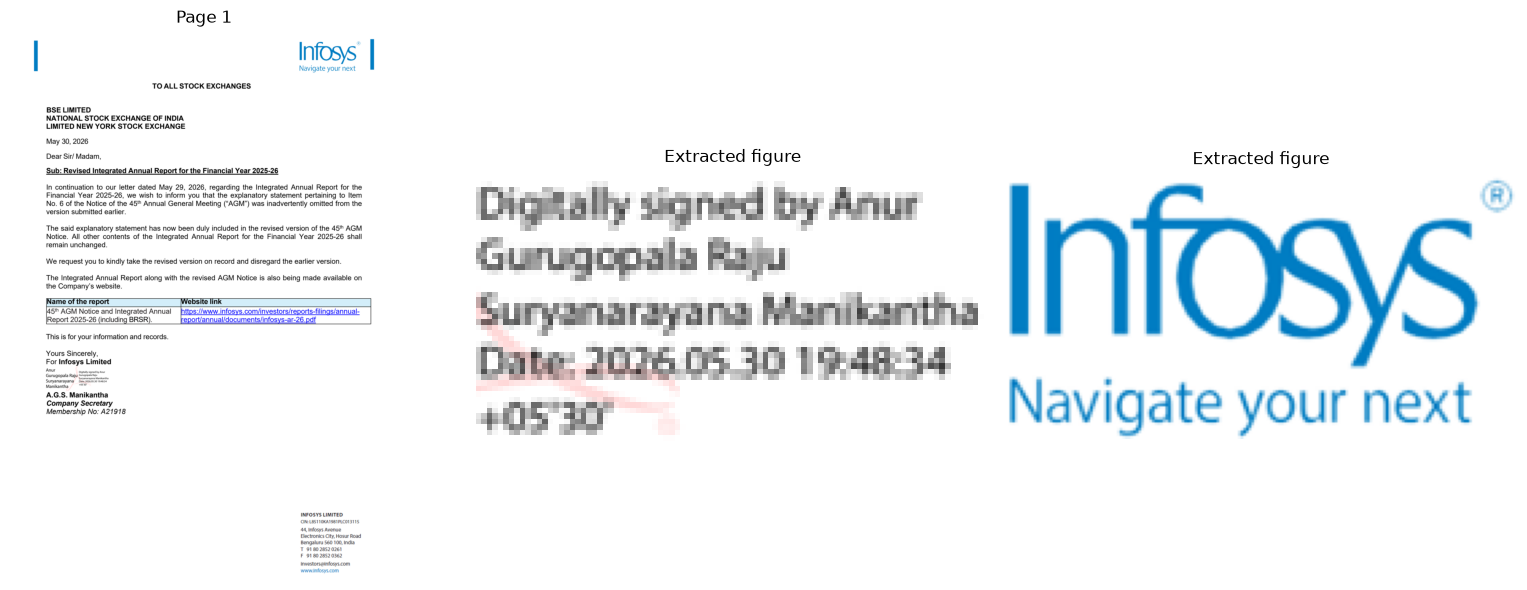

In [17]:

# Preview a page and a couple of figure crops inline.
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
first_page_no = next(iter(report_doc.pages))
axes[0].imshow(report_doc.pages[first_page_no].image.pil_image)
axes[0].set_title(f"Page {first_page_no}")
axes[0].axis("off")

pics = [it for it, _ in report_doc.iterate_items() if isinstance(it, PictureItem)]
for ax, pic in zip(axes[1:], pics[:2]):
    ax.imshow(pic.get_image(report_doc))
    ax.set_title("Extracted figure")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 6. Markdown/HTML export with embedded vs. referenced images

`ImageRefMode` controls how images show up in exported Markdown/HTML: `EMBEDDED` (base64
inline — one self-contained file), `REFERENCED` (external files, smaller export, needs the
asset folder alongside it), or `PLACEHOLDER` (just a `<!-- image -->` marker, used above).


In [36]:

report_doc.save_as_markdown(OUT_DIR / "infosys-with-images.md", image_mode=ImageRefMode.EMBEDDED)
report_doc.save_as_markdown(OUT_DIR / "infosys-with-image-refs.md", image_mode=ImageRefMode.REFERENCED)
report_doc.save_as_html(OUT_DIR / "infosys-with-image-refs.html", image_mode=ImageRefMode.REFERENCED)

for f in ["infosys-with-images.md", "infosys-with-image-refs.md", "infosys-with-image-refs.html"]:
    p = OUT_DIR / f
    print(f"{f:32s} {p.stat().st_size / 1024:.1f} KB")


NameError: name 'report_doc' is not defined

## 7. OCR — engines, forcing, and language control

The default `OcrAutoOptions` picks whichever OCR backend is actually installed (RapidOCR
here). You can force full-page OCR (ignore the digital text layer entirely and re-derive
everything from pixels — useful for scanned pages or PDFs with a broken/garbled text layer),
switch engines (`EasyOcrOptions`, `TesseractOcrOptions`/`TesseractCliOcrOptions`, `OcrMacOptions`,
`RapidOcrOptions`), and set target languages.


In [19]:

from docling.datamodel.pipeline_options import RapidOcrOptions

# Native pipeline: OCR only kicks in where the digital text layer is missing/unreliable.
native_res = quick_res  # already converted in section 1 with default settings

# Force full-page OCR: every page is re-derived from the rendered bitmap via RapidOCR,
# ignoring the PDF's embedded text layer entirely.
forced_ocr_opts = PdfPipelineOptions()
forced_ocr_opts.do_ocr = True
forced_ocr_opts.ocr_options = RapidOcrOptions(force_full_page_ocr=True)
forced_ocr_converter = DocumentConverter(format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=forced_ocr_opts)})

t0 = time.time()
forced_res = forced_ocr_converter.convert(str(QUICK_PDF), page_range=(1, 2))
print(f"Forced full-page OCR on 2 pages: {time.time()-t0:.1f}s")


[INFO] 2026-07-05 14:33:51,014 [RapidOCR] base.py:22: Using engine_name: onnxruntime


[INFO] 2026-07-05 14:33:51,014 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx


[INFO] 2026-07-05 14:33:51,014 [RapidOCR] main.py:65: Using D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx


[INFO] 2026-07-05 14:33:51,127 [RapidOCR] base.py:22: Using engine_name: onnxruntime


[INFO] 2026-07-05 14:33:51,127 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx


...

[INFO] 2026-07-05 14:33:51,178 [RapidOCR] base.py:22: Using engine_name: onnxruntime


[INFO] 2026-07-05 14:33:51,189 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_rec_mobile.onnx


[INFO] 2026-07-05 14:33:51,189 [RapidOCR] main.py:65: Using D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_rec_mobile.onnx


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Forced full-page OCR on 2 pages: 32.2s


In [20]:

native_text = native_res.document.export_to_markdown()[:400]
forced_text = forced_res.document.export_to_markdown()[:400]

print("Native (digital text layer), first 400 chars:\n", native_text)
print("\nForced full-page OCR (RapidOCR), first 400 chars:\n", forced_text)
print("\n(On a clean digital PDF like this one the two should read almost identically --")
print(" the interesting case is scanned/garbled PDFs, where forced OCR recovers text the")
print(" native layer can't.)")


Native (digital text layer), first 400 chars:
 ## Prevalence of and Risk Factors for Post-COVID-19 Condition during Omicron BA.5Dominant Wave, Japan

Arisa Iba, Mariko Hosozawa, Miyuki Hori, Yoko Muto, Isao Muraki, Rie Masuda, Nanako Tamiya, Hiroyasu Iso

The  increased  risk  for  post-COVID-19  condition  after the Omicron-dominant wave remains unclear. This pop -ulation-based study included 25,911 persons in Japan 20-69 years of age with co

Forced full-page OCR (RapidOCR), first 400 chars:
 ## Prevalence of and Risk Factors for Post-COVID-19 Condition during Omicron BA.5Dominant Wave, Japan

ArisaIba,MarikoHosozawa,MiyukiHori,YokoMuto, Isao Muraki,Rie Masuda,Nanako Tamiya,Hiroyasu Iso

Theincreasedriskforpost-COVID-19conditionafter the Omicron-dominant wave remains unclear. This population-based study included 25,911 persons in Japan 20-69years of age withconfirmedSARS-CoV-2 infectio

(On a clean digital PDF like this one the two should read almost identically --
 the interesting c

## 8. Non-generative enrichments: picture classification, code, formulas

These are specialized classifier/encoder models, not chat-style VLMs — no free-text
generation, just structured labels:

- **Picture classification** (`do_picture_classification`): tags each figure with a class —
  `chart`, `logo`, `flow_chart`, `signature`, `table`, `photograph`, etc. Great for deciding
  *whether* a figure is worth describing/indexing at all before spending any VLM budget on it.
- **Code understanding** (`do_code_enrichment`): parses detected code blocks, sets
  `CodeItem.code_language`.
- **Formula understanding** (`do_formula_enrichment`): extracts LaTeX for detected equations.


In [21]:

from collections import Counter

classified_pics = [p for p in report_doc.pictures if p.meta and p.meta.classification]
print(f"{len(classified_pics)}/{len(report_doc.pictures)} pictures got a classification (pages 1-15 of {REPORT_PDF.name})")

top_class_counts = Counter()
for p in classified_pics:
    main = p.meta.classification.get_main_prediction()
    if main:
        top_class_counts[main.class_name] += 1

print("\nTop predicted classes:")
for cls, n in top_class_counts.most_common():
    print(f"  {cls:24s} {n}")


65/65 pictures got a classification (pages 1-15 of infosys_filing_2026.pdf)

Top predicted classes:
  photograph               44
  logo                     10
  icon                     8
  other                    1
  engineering_drawing      1
  geographical_map         1


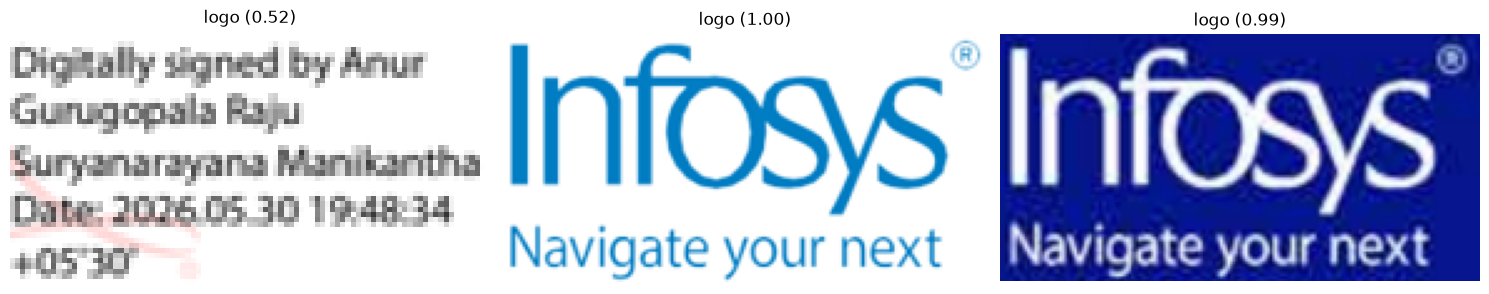

In [22]:

# Show a couple of examples with their top-1 label + confidence.
fig, axes = plt.subplots(1, min(3, len(classified_pics)), figsize=(15, 5))
if len(classified_pics) == 1:
    axes = [axes]
for ax, pic in zip(axes, classified_pics[:3]):
    main = pic.meta.classification.get_main_prediction()
    ax.imshow(pic.get_image(report_doc))
    ax.set_title(f"{main.class_name} ({main.confidence:.2f})")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [23]:

# Code + formula enrichment: cheap to enable, but these are regulatory/financial documents,
# so we don't expect actual CodeItem/formula hits -- this just proves the toggle works and
# shows how you'd inspect results if the source were a technical/scientific paper instead.
code_formula_opts = PdfPipelineOptions()
code_formula_opts.do_code_enrichment = True
code_formula_opts.do_formula_enrichment = True
cf_converter = DocumentConverter(format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=code_formula_opts)})

t0 = time.time()
cf_res = cf_converter.convert(str(PRIMARY_PDF), page_range=(1, 5))
print(f"Converted with code+formula enrichment in {time.time()-t0:.1f}s")

code_items = [t for t in cf_res.document.texts if t.label == DocItemLabel.CODE]
print(f"CodeItems found: {len(code_items)} (expected ~0 -- this is a regulations PDF, not source code)")


[INFO] 2026-07-05 14:34:23,407 [RapidOCR] base.py:22: Using engine_name: onnxruntime


[INFO] 2026-07-05 14:34:23,407 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx


[INFO] 2026-07-05 14:34:23,407 [RapidOCR] main.py:65: Using D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx


[INFO] 2026-07-05 14:34:23,518 [RapidOCR] base.py:22: Using engine_name: onnxruntime


[INFO] 2026-07-05 14:34:23,518 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx


...

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie model.text_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Converted with code+formula enrichment in 18.6s
CodeItems found: 0 (expected ~0 -- this is a regulations PDF, not source code)


## 9. Confidence scores — knowing when to trust (or re-run) a conversion

Every `ConversionResult` carries a `confidence` report: per-page and document-level grades
(`POOR`/`FAIR`/`GOOD`/`EXCELLENT`) covering layout recognition, OCR quality, and parse quality.
This is the natural signal for "flag this document for manual review" or "retry with forced
OCR / a different backend" in an automated ingestion pipeline — exactly the kind of thing
the Edenview ingestion job status should surface.


In [24]:

conf = quick_res.confidence
print(f"Document-level: mean_grade={conf.mean_grade.value}  low_grade={conf.low_grade.value}")
print(f"  layout_score={conf.layout_score:.3f}  ocr_score={conf.ocr_score:.3f}  parse_score={conf.parse_score:.3f}")

print("\nPer-page grades:")
for page_no, page_conf in sorted(conf.pages.items()):
    print(f"  page {page_no:>2}: mean={page_conf.mean_grade.value:<10} low={page_conf.low_grade.value:<10} "
          f"(layout={page_conf.layout_score:.2f})")


Document-level: mean_grade=excellent  low_grade=excellent
  layout_score=0.906  ocr_score=0.976  parse_score=1.000

Per-page grades:
  page  1: mean=excellent  low=good       (layout=0.84)
  page  2: mean=excellent  low=excellent  (layout=0.95)
  page  3: mean=excellent  low=excellent  (layout=0.96)
  page  4: mean=excellent  low=good       (layout=0.86)
  page  5: mean=excellent  low=good       (layout=0.84)
  page  6: mean=excellent  low=excellent  (layout=0.92)
  page  7: mean=excellent  low=good       (layout=0.86)
  page  8: mean=excellent  low=excellent  (layout=0.95)
  page  9: mean=excellent  low=excellent  (layout=0.97)
  page 10: mean=excellent  low=excellent  (layout=0.92)


In [25]:

# A simple review-queue rule: flag any page whose *low* grade drops below GOOD.
from docling.datamodel.base_models import QualityGrade

acceptable = {QualityGrade.GOOD, QualityGrade.EXCELLENT}
flagged = [pn for pn, pc in conf.pages.items() if pc.low_grade not in acceptable]
print(f"Pages flagged for manual review: {flagged or 'none'}")


Pages flagged for manual review: none


### Robustness callout: `PARTIAL_SUCCESS` is real, and confidence scores catch it

Not a hypothetical: converting `wc-2026-regulations.pdf` **end-to-end** (all 50 pages, no
`page_range`) on this machine intermittently raises `std::bad_alloc` inside the native PDF
backend somewhere past page ~20 -- almost certainly a memory-pressure issue on this
particular box rather than anything wrong with those pages. Docling doesn't crash the whole
conversion though: it marks the result `PARTIAL_SUCCESS`, keeps everything that *did* parse,
and records which pages failed. This is exactly the kind of failure an ingestion service has
to handle gracefully instead of silently shipping a half-empty document to the vector store.

The detection pattern: check `result.status`, walk `result.errors` for which pages failed,
and cross-check against `result.confidence.pages` — a page missing from that dict entirely
means it never got scored because it never got processed.


In [26]:

full_res = default_converter.convert(str(PRIMARY_PDF))  # no page_range: process all 50 pages
print("status:", full_res.status.name)

if full_res.errors:
    failed_pages = sorted({
        int(e.error_message.split(":")[0].replace("Page", "").strip())
        for e in full_res.errors
    })
    print(f"{len(full_res.errors)} page-level errors, pages affected: {failed_pages}")
    print("Sample error:", full_res.errors[0].error_message)

    # Pages that failed never made it into the confidence report at all.
    missing_from_confidence = [p for p in failed_pages if p not in full_res.confidence.pages]
    print(f"Failed pages absent from confidence.pages (as expected): {missing_from_confidence[:10]}...")
else:
    print("Converted cleanly this run -- the bad_alloc is intermittent, not deterministic, on this machine.")


ERROR:docling.pipeline.standard_pdf_pipeline:Stage preprocess failed for run 4, pages [17]: std::bad_alloc


ERROR:docling.pipeline.standard_pdf_pipeline:Stage preprocess failed for run 4, pages [18]: std::bad_alloc


ERROR:docling.pipeline.standard_pdf_pipeline:Stage preprocess failed for run 4, pages [19]: std::bad_alloc


ERROR:docling.pipeline.standard_pdf_pipeline:Stage preprocess failed for run 4, pages [20]: std::bad_alloc


ERROR:docling.pipeline.standard_pdf_pipeline:Stage preprocess failed for run 4, pages [21]: std::bad_alloc


...

ERROR:docling.pipeline.standard_pdf_pipeline:Stage preprocess failed for run 4, pages [47]: std::bad_alloc


ERROR:docling.pipeline.standard_pdf_pipeline:Stage preprocess failed for run 4, pages [48]: std::bad_alloc


ERROR:docling.pipeline.standard_pdf_pipeline:Stage preprocess failed for run 4, pages [49]: std::bad_alloc


ERROR:docling.pipeline.standard_pdf_pipeline:Stage preprocess failed for run 4, pages [50]: std::bad_alloc


status: PARTIAL_SUCCESS
33 page-level errors, pages affected: [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
Sample error: Page 20: std::bad_alloc
Failed pages absent from confidence.pages (as expected): [17, 18, 19, 20, 21, 22, 23, 24, 25, 26]...


## 10. Pipeline & performance controls

A grab-bag of options that matter once this moves from a notebook to a service:

- `page_range=(start, end)` — actually truncates processing to a page window; this is the
  "fast preview on first N pages" hook mentioned in the Edenview plan.
- `max_num_pages` / `max_file_size` — a different thing: hard guard rails that reject the
  *entire* document up front if it's bigger than the cap, rather than truncating it. Good for
  "refuse anything over 500 pages / 50MB at the API boundary," not for previewing.
- `AcceleratorOptions` — pin CPU thread count / device explicitly instead of relying on
  environment defaults.
- Binary stream conversion via `DocumentStream` — convert an in-memory upload without
  touching disk (what a FastAPI upload endpoint would actually do).
- `artifacts_path` / `DOCLING_ARTIFACTS_PATH` — prefetch model weights once for fully
  offline / air-gapped operation (relevant since Edenview promises "no cloud dependency by
  default").


In [27]:

from docling.datamodel.accelerator_options import AcceleratorDevice, AcceleratorOptions

cpu_opts = PdfPipelineOptions()
cpu_opts.accelerator_options = AcceleratorOptions(num_threads=4, device=AcceleratorDevice.CPU)
cpu_converter = DocumentConverter(format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=cpu_opts)})

# `page_range` is the truncation knob -- it actually limits *which* pages get processed.
t0 = time.time()
limited_res = cpu_converter.convert(str(FINANCIAL_PDF), page_range=(1, 5))
print(f"page_range=(1,5), 4 CPU threads: {time.time()-t0:.1f}s, pages kept={len(limited_res.document.pages)}")


[INFO] 2026-07-05 14:35:21,558 [RapidOCR] base.py:22: Using engine_name: onnxruntime


[INFO] 2026-07-05 14:35:21,574 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx


[INFO] 2026-07-05 14:35:21,574 [RapidOCR] main.py:65: Using D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx


[INFO] 2026-07-05 14:35:21,693 [RapidOCR] base.py:22: Using engine_name: onnxruntime


[INFO] 2026-07-05 14:35:21,693 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx


...

[INFO] 2026-07-05 14:35:21,748 [RapidOCR] base.py:22: Using engine_name: onnxruntime


[INFO] 2026-07-05 14:35:21,748 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_rec_mobile.onnx


[INFO] 2026-07-05 14:35:21,748 [RapidOCR] main.py:65: Using D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_rec_mobile.onnx


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

page_range=(1,5), 4 CPU threads: 16.7s, pages kept=5


In [28]:

# `max_num_pages` (and `max_file_size`) are guard rails, NOT truncation -- they reject the
# *whole* document outright if it exceeds the limit, rather than processing a prefix of it.
# Useful as an ingestion safety net ("refuse anything over N pages / N MB") but it's easy to
# confuse with page_range, so worth proving out explicitly:
from docling.exceptions import ConversionError

print(f"{FINANCIAL_PDF.name} has 104 pages total (see intro table) -- well over the max_num_pages=5 cap below.")
try:
    default_converter.convert(str(FINANCIAL_PDF), max_num_pages=5)
    print("Unexpectedly succeeded")
except ConversionError as e:
    print(f"Rejected as expected: {e}")


vistra-20260331.pdf has 104 pages total (see intro table) -- well over the max_num_pages=5 cap below.
Rejected as expected: Input document vistra-20260331.pdf is not valid.


In [29]:

from io import BytesIO
from docling.datamodel.base_models import DocumentStream

# Simulates what a FastAPI upload handler receives: raw bytes, not a filesystem path.
with open(QUICK_PDF, "rb") as fh:
    raw_bytes = fh.read()

stream_source = DocumentStream(name="uploaded.pdf", stream=BytesIO(raw_bytes))
stream_res = default_converter.convert(stream_source, page_range=(1, 1))
print("Converted from an in-memory byte stream:")
print(" ", stream_res.document.export_to_markdown()[:200])


Converted from an in-memory byte stream:
  ## Prevalence of and Risk Factors for Post-COVID-19 Condition during Omicron BA.5Dominant Wave, Japan

Arisa Iba, Mariko Hosozawa, Miyuki Hori, Yoko Muto, Isao Muraki, Rie Masuda, Nanako Tamiya, Hiroy


## 11. Chunking — native Docling chunkers

Docling ships chunkers that operate directly on a `DoclingDocument` (as opposed to
re-chunking exported Markdown yourself). All chunk metadata carries back-references
(`self_ref`, provenance) to the original doc items, so citations stay grounded.

- **`HybridChunker`** — hierarchical chunking + tokenizer-aware refinement (merges small
  sibling chunks, splits oversized ones) against a target embedding model's tokenizer. This
  is the one you'd wire up to whatever embedding model Edenview selects.
- **`HierarchicalChunker`** — the structural pass without tokenization awareness; good for
  seeing "pure" document-structure chunks before token budgets get involved.
- **`LineBasedTokenChunker`** — chunks line-oriented content (e.g. table rows already
  flattened to text) under a token budget, with an optional repeated prefix (e.g. a table
  header) per chunk.


In [30]:

from docling.chunking import HybridChunker, HierarchicalChunker

hybrid_chunker = HybridChunker()
hybrid_chunks = list(hybrid_chunker.chunk(dl_doc=primary_doc))
print(f"HybridChunker produced {len(hybrid_chunks)} chunks from {PRIMARY_PDF.name}")

for i, chunk in enumerate(hybrid_chunks[:3]):
    print(f"\n=== chunk {i} ===")
    print("chunk.text:", chunk.text[:200].replace(chr(10), " "), "...")
    print("contextualized:", hybrid_chunker.contextualize(chunk=chunk)[:200].replace(chr(10), " "), "...")
    print("doc_items:", [it.self_ref for it in chunk.meta.doc_items])


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1489 > 512). Running this sequence through the model will result in indexing errors


HybridChunker produced 65 chunks from wc-2026-regulations.pdf

=== chunk 0 ===
chunk.text: Telephone: Website:, Football Association Gianni Infantino Mattias Grafström FIFA FIFA-Strasse 20 = Switzerland +41 (0)43 222 7777 FIFA.com. Organising Committee for Chairman: Address:, Football Assoc ...
contextualized: Regulations for the FIFA World Cup 26™ 11 June - 19 July 2026 Telephone: Website:, Football Association Gianni Infantino Mattias Grafström FIFA FIFA-Strasse 20 = Switzerland +41 (0)43 222 7777 FIFA.co ...
doc_items: ['#/tables/0']

=== chunk 1 ===
chunk.text: I . ...
contextualized: TABLE OF CONTENTS I . ...
doc_items: ['#/texts/5', '#/texts/6']

=== chunk 2 ===
chunk.text:  Article 1:, GENERAL PROVISIONS = FIFA World Cup™. Article 1:, 7 = 8. Article 2:, GENERAL PROVISIONS = Preliminary competition. Article 2:, 7 = 9. Article 3:, GENERAL PROVISIONS = FIFA organising body ...
contextualized: TABLE OF CONTENTS  Article 1:, GENERAL PROVISIONS = FIFA World Cup™. Article 1:, 7 = 8. Ar

In [31]:

hier_chunker = HierarchicalChunker()
hier_chunks = list(hier_chunker.chunk(dl_doc=primary_doc))
print(f"HierarchicalChunker (no tokenizer awareness): {len(hier_chunks)} chunks")
print(f"HybridChunker (tokenizer-aware merge/split):  {len(hybrid_chunks)} chunks")
print("\n(HybridChunker typically produces fewer, more evenly-sized chunks -- it merges")
print(" tiny structural fragments and splits any chunk that overflows the tokenizer's")
print(" max sequence length.)")


HierarchicalChunker (no tokenizer awareness): 78 chunks
HybridChunker (tokenizer-aware merge/split):  65 chunks

(HybridChunker typically produces fewer, more evenly-sized chunks -- it merges
 tiny structural fragments and splits any chunk that overflows the tokenizer's
 max sequence length.)


In [32]:

# Token-count distribution -- the number you actually care about when picking chunk_size
# for an embedding model.
from docling.chunking import HybridChunker

default_tokenizer = hybrid_chunker.tokenizer
token_counts = [default_tokenizer.count_tokens(text=hybrid_chunker.contextualize(chunk=c)) for c in hybrid_chunks]

s = pd.Series(token_counts)
print(s.describe())


count     65.000000
mean     191.846154
std       73.852308
min        4.000000
25%      163.000000
50%      213.000000
75%      248.000000
max      263.000000
dtype: float64


In [33]:

from docling_core.transforms.chunker.line_chunker import LineBasedTokenChunker
from docling_core.transforms.chunker.tokenizer.huggingface import HuggingFaceTokenizer
from transformers import AutoTokenizer

# Note: max_tokens lives on the *tokenizer*, not the chunker -- LineBasedTokenChunker only
# takes tokenizer/prefix/omit_prefix_on_overflow/delim. And its low-level entry point,
# chunk_text(lines=...), takes plain strings and returns plain strings (not DocChunk objects
# with provenance) -- it's meant for pre-flattened content like table rows, not a DoclingDocument.
line_tokenizer = HuggingFaceTokenizer(
    tokenizer=AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2"),
    max_tokens=64,
)

# Feed it flattened rows from an extracted table -- this is the realistic use case:
# wide/long tables where you want each chunk to repeat the header for context.
# Pick the table with the most rows so the chunk boundary/prefix-repeat is actually visible.
if fin_doc.tables:
    all_dfs = [t.export_to_dataframe(doc=fin_doc) for t in fin_doc.tables]
    df = max(all_dfs, key=lambda d: d.shape[0])
    header = " | ".join(str(c) for c in df.columns) + "\n"
    rows = [" | ".join(str(v) for v in row) + "\n" for row in df.itertuples(index=False)]

    line_chunker = LineBasedTokenChunker(tokenizer=line_tokenizer, prefix=header)
    line_chunks = line_chunker.chunk_text(lines=rows)
    print(f"Chunked {len(rows)} table rows into {len(line_chunks)} chunks (header prefix repeated each time):\n")
    for c in line_chunks[:2]:
        print(repr(c[:300]))
        print("---")
else:
    print("No tables in this page range to demo LineBasedTokenChunker on.")


Chunked 45 table rows into 8 chunks (header prefix repeated each time):

' |  | PAGE\nGlossary of Terms and Abbreviations | Glossary of Terms and Abbreviations | ii\nForward-Looking Statements | Forward-Looking Statements | v\nPART I. | FINANCIALINFORMATION | 1\nItem 1. | Financial Statements (Unaudited) | 1\n | Condensed Consolidated Statements of Operations | 1\n'
---
' |  | PAGE\n | Condensed Consolidated Balance Sheets | 2\n | Condensed Consolidated Statements of Cash Flows | 4\n | Condensed Consolidated Statements of Changes in Equity | 6\n | Notes to Condensed Consolidated Financial Statements | 7\n | 1. Business and Significant Accounting Policies | 7\n | 2. Acquis'
---


## 12. Serialization customization

Chunking is built on top of a **serializer**: the thing that turns a table/picture/text item
into the string that actually goes into the chunk. You can swap serializers per item type —
e.g. render tables as Markdown instead of the default triplet notation, or attach structured
picture-classification metadata as text instead of a bare placeholder.


In [34]:

from docling_core.transforms.chunker.hierarchical_chunker import ChunkingDocSerializer, ChunkingSerializerProvider
from docling_core.transforms.serializer.markdown import MarkdownTableSerializer

class MDTableSerializerProvider(ChunkingSerializerProvider):
    def get_serializer(self, doc):
        return ChunkingDocSerializer(doc=doc, table_serializer=MarkdownTableSerializer())

md_table_chunker = HybridChunker(serializer_provider=MDTableSerializerProvider())
md_table_chunks = list(md_table_chunker.chunk(dl_doc=fin_doc))

# Target the largest table specifically (by row count) -- it's the one most likely to get
# split across chunk boundaries by the tokenizer budget, which is what makes the chunk
# expansion demo below actually interesting.
biggest_table_ref = max(fin_doc.tables, key=lambda t: t.export_to_dataframe(doc=fin_doc).shape[0]).self_ref
table_chunk = next(
    (c for c in md_table_chunks if any(it.self_ref == biggest_table_ref for it in c.meta.doc_items)),
    None,
)
if table_chunk:
    print(f"Chunk containing table {biggest_table_ref}, serialized as Markdown instead of the default triplet form:\n")
    print(md_table_chunker.contextualize(chunk=table_chunk)[:600])


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (635 > 512). Running this sequence through the model will result in indexing errors


D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\docling_core\transforms\chunker\line_chunker.py:83: UserWarning: Chunks prefix is too long (422 tokens) for chunk size 256. It will be split into multiple chunks and only included in the first chunk(s). Consider increasing max_tokens to accommodate the full prefix in each chunk.
  warnings.warn(
D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\docling_core\transforms\chunker\line_chunker.py:83: UserWarning: Chunks prefix is too long (346 tokens) for chunk size 256. It will be split into multiple chunks and only included in the first chunk(s). Consider increasing max_tokens to accommodate the full prefix in each chunk.
  warnings.warn(
D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\docling_core\transforms\chunker\line_chunker.py:83: UserWarning: Chunks prefix is too long (463 tokens) for chunk size 256. It will be split into multiple chunks and only included in the first chunk(s). Consider increasing max_tokens to a

Chunk containing table #/tables/1, serialized as Markdown instead of the default triplet form:

TABLE OF CONTENTS
|                                     |                                                                          | PAGE   |

|-------------------------------------|--------------------------------------------------------------------------|--------|
| Glossary of Terms and Abbreviations | Glossary of Terms and Abbreviations                                      | ii     |
| Forward-Looking Statements          | Forward-Looking Statements                                               | v      |
| PART I.                             | FINANCIALINFORMATION                         


In [35]:

from docling_core.transforms.serializer.base import BaseDocSerializer, SerializationResult
from docling_core.transforms.serializer.common import create_ser_result
from docling_core.transforms.serializer.markdown import MarkdownPictureSerializer
from docling_core.types.doc.document import PictureItem as _PictureItem
from typing_extensions import override

class ClassificationAwarePictureSerializer(MarkdownPictureSerializer):
    @override
    def serialize(self, *, item, doc_serializer, doc, **kwargs) -> SerializationResult:
        parts = []
        if item.meta is not None and item.meta.classification is not None:
            main = item.meta.classification.get_main_prediction()
            if main is not None:
                parts.append(f"[figure type: {main.class_name}, confidence {main.confidence:.2f}]")
        text = doc_serializer.post_process(text="\n".join(parts))
        return create_ser_result(text=text, span_source=item)

class PicClassSerializerProvider(ChunkingSerializerProvider):
    def get_serializer(self, doc):
        return ChunkingDocSerializer(doc=doc, picture_serializer=ClassificationAwarePictureSerializer())

pic_chunker = HybridChunker(serializer_provider=PicClassSerializerProvider())
pic_chunks = list(pic_chunker.chunk(dl_doc=report_doc))

pic_chunk = next((c for c in pic_chunks if any(it.self_ref.startswith("#/pictures") for it in c.meta.doc_items)), None)
if pic_chunk:
    print("Picture chunk carrying its classification label as retrievable text:\n")
    print(pic_chunker.contextualize(chunk=pic_chunk)[:400])
else:
    print("No picture-containing chunk in this range.")


Picture chunk carrying its classification label as retrievable text:

Sub: Revised Integrated Annual Report for the Financial Year 2025-26
In  continuation  to  our  letter  dated  May  29,  2026,  regarding  the  Integrated  Annual  Report  for  the Financial Year 2025-26, we wish to inform you that the explanatory statement pertaining to Item No. 6 of the Notice of the 45 th  Annual General Meeting ('AGM') was inadvertently omitted from the version submitted earli


### Chunk expansion

Sometimes a chunk boundary lands in the middle of a semantic unit (e.g. a large table gets
truncated by the token budget). `TreeChunkExpander` expands a chunk back out to its full
containing doc item; `PageChunkExpander` expands to everything on the same page — handy
when you want full-page context for QA regardless of where the chunk boundary fell.


In [36]:

from docling_core.transforms.chunker.chunk_expander import TreeChunkExpander, PageChunkExpander

if table_chunk:
    serializer = MDTableSerializerProvider().get_serializer(doc=fin_doc)
    tree_expander = TreeChunkExpander()
    expanded = tree_expander.expand(chunk=table_chunk, dl_doc=fin_doc, serializer=serializer)

    orig_tokens = default_tokenizer.count_tokens(text=md_table_chunker.contextualize(chunk=table_chunk))
    exp_tokens = default_tokenizer.count_tokens(text=md_table_chunker.contextualize(chunk=expanded))
    print(f"Original chunk: {orig_tokens} tokens -> expanded to full table: {exp_tokens} tokens")


Original chunk: 255 tokens -> expanded to full table: 635 tokens


## 13. Visual grounding without a VLM

"Visual grounding" here just means: every extracted item carries `provenance` (page number +
bounding box), so you can draw a box around exactly where an answer's supporting chunk came
from on the original page image. No vision model needed — this is pure geometry from the
layout model's output, and it's the mechanism behind the "inline source citations" view in
the Edenview chat UI.


[INFO] 2026-07-05 14:35:42,765 [RapidOCR] base.py:22: Using engine_name: onnxruntime


[INFO] 2026-07-05 14:35:42,765 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx


[INFO] 2026-07-05 14:35:42,765 [RapidOCR] main.py:65: Using D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx


[INFO] 2026-07-05 14:35:42,875 [RapidOCR] base.py:22: Using engine_name: onnxruntime


[INFO] 2026-07-05 14:35:42,875 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx


...

[INFO] 2026-07-05 14:35:42,923 [RapidOCR] base.py:22: Using engine_name: onnxruntime


[INFO] 2026-07-05 14:35:42,923 [RapidOCR] download_file.py:60: File exists and is valid: D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_rec_mobile.onnx


[INFO] 2026-07-05 14:35:42,923 [RapidOCR] main.py:65: Using D:\Work\Github\local-agentic-rag\venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_rec_mobile.onnx


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2549 > 512). Running this sequence through the model will result in indexing errors


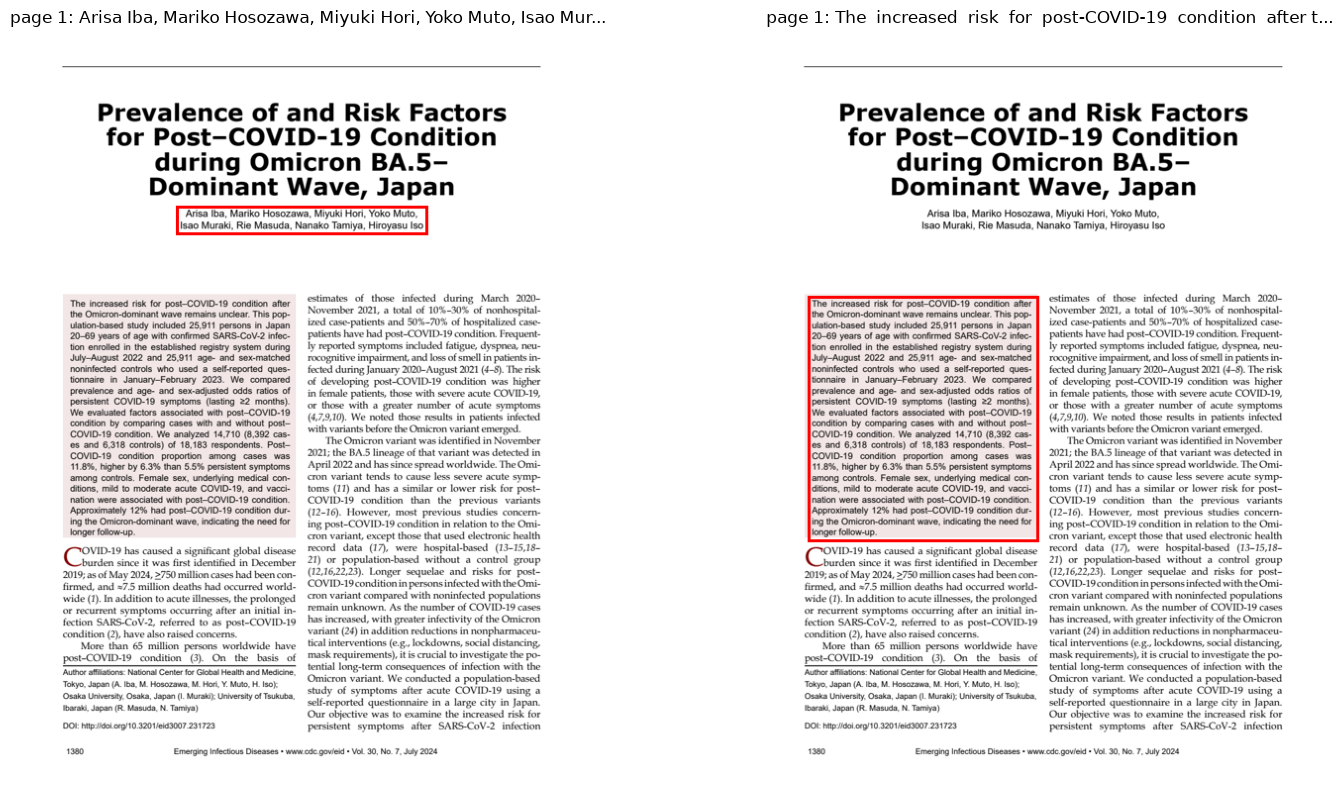

In [37]:

def draw_provenance(doc, item, color="red", padding=4):
    prov = item.prov[0]
    page = doc.pages[prov.page_no]
    img = page.image.pil_image.copy()
    bbox = prov.bbox.to_top_left_origin(page_height=page.size.height).normalized(page.size)
    draw = ImageDraw.Draw(img)
    box = (
        round(bbox.l * img.width - padding),
        round(bbox.t * img.height - padding),
        round(bbox.r * img.width + padding),
        round(bbox.b * img.height + padding),
    )
    draw.rectangle(box, outline=color, width=3)
    return img, prov.page_no

# We need page images for the quick doc -- re-convert with generate_page_images=True.
vg_opts = PdfPipelineOptions()
vg_opts.generate_page_images = True
vg_converter = DocumentConverter(format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=vg_opts)})
vg_res = vg_converter.convert(str(QUICK_PDF))
vg_doc = vg_res.document

# Ground a couple of hybrid chunks visually.
vg_chunks = list(HybridChunker().chunk(dl_doc=vg_doc))
sample_chunks = [c for c in vg_chunks if c.meta.doc_items and c.meta.doc_items[0].prov][:2]

fig, axes = plt.subplots(1, len(sample_chunks), figsize=(8 * len(sample_chunks), 8))
if len(sample_chunks) == 1:
    axes = [axes]
for ax, chunk in zip(axes, sample_chunks):
    item = chunk.meta.doc_items[0]
    # resolve the actual DocItem so we can access .prov / bbox
    doc_item = next(it for it, _ in vg_doc.iterate_items() if it.self_ref == item.self_ref)
    img, page_no = draw_provenance(vg_doc, doc_item)
    ax.imshow(img)
    ax.set_title(f"page {page_no}: {chunk.text[:60].strip()}...")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 14. Summary — what this means for Edenview

Mapping back to `edenview_plan.md` (Section 5.1 ingestion module, Section 6 architectural
decisions):

| Docling capability demonstrated | Edenview touchpoint |
|---|---|
| Unified `DoclingDocument` across PDF/DOCX/HTML/CSV/... | `extractor.py` needs to be a thin wrapper — Docling already normalizes formats |
| `page_range` (truncate) vs. `max_num_pages`/`max_file_size` (reject) | `page_range` directly implements the "fast preview on first ~5 pages" requirement (`POST /rag/preview`); the other two are ingestion guard rails, not a preview mechanism |
| `TableFormerMode.FAST` vs `ACCURATE` | A real lever for the preview-vs-full-ingest quality/speed tradeoff, not just page count |
| Confidence scores (page + doc grade) | Natural signal for ingestion job status ("needs review") beyond just success/failure |
| Native chunkers (`HybridChunker`, `HierarchicalChunker`, `LineBasedTokenChunker`) | Could directly back the "Parent-child" / "Fixed + overlap" chunk mode selector instead of hand-rolling chunkers |
| Custom serializers (table-as-Markdown, classification-aware pictures) | Lets the contextual/semantic chunk modes carry richer per-item metadata into the embedded text |
| Provenance (page_no + bbox) on every item | Powers inline citation highlighting in the Chat view for free — no VLM, no extra indexing |
| Picture classification (non-generative) | Cheap pre-filter for "is this figure worth describing/indexing" before spending any VLM budget |
| `DocumentStream` (binary conversion) | Matches how a FastAPI upload endpoint actually receives files — no temp file needed |
| `AcceleratorOptions` / `artifacts_path` prefetch | Needed for the "no cloud dependency by default" / offline promise in the Docker Compose stack |

**Deliberately not covered here (VLM-dependent, revisit later):** `do_picture_description`
(captioning), the GraniteDocling/SmolDocling full-page VLM pipeline, and PII
detection/obfuscation (which needs an extra NER model download — worth its own notebook
once we're past core extraction).
